# Detecção de Fraude em Transações de Cartão de Crédito
**Disciplina:** Inteligência Artificial – 7ºJ SI - Noite
**Professor:** Prof. Dr. Leandro Zerbinatti

**Integrantes do grupo:**
- Anna Julia — 10420681 / 10420681@mackenzista.com.br
- Eduarda — 10419951 / 10419951@mackenzista.com.br
- Sara —  10425441 / 10425441@mackenzista.com.br

**Síntese do conteúdo deste arquivo:** Análise exploratória dos dados (parte da Eduarda) 
carregamento do dataset `creditcard.csv`, inspeção geral (`info()`, `describe()`), verificação de valores nulos e duplicados, e análise do desbalanceamento da variável `Class` (fraude ≈0,17% vs. legítima ≈99,83%), com gráficos de barras  e pizza.

**Histórico de alterações:**

| Data | Autor | Descrição |
|---|---|---|
| 13/09/2026 | Eduarda Dantas | Criação do notebook  e Construção|
| 14/09/2026 | Eduarda Dantas | Construção |


## 1. Importação das bibliotecas e carregamento do dataset
> Obs.: a preparação dos dados para modelagem (split treino/teste, normalização, SMOTE) é a parte da Anna Julia (`preparacao_dados.ipynb`) — aqui fica só a análise exploratória.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Config para a Exibição
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

#   dataset
df = pd.read_csv('../dataset/creditcard.csv')

print(f'Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Dimensões do dataset: 284807 linhas x 31 colunas


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Informações gerais do dataset

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 3. Estatísticas descritivas (`describe()`)

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Observações `describe()`:
- As variáveis `V1` a `V28` já estão padronizadas/transformadas via PCA (por isso possuem médias
  próximas de zero e escalas semelhantes entre si).



## 4. Verificação de valores nulos

In [ ]:
nulos = df.isnull().sum()
total_nulos = nulos.sum()

print('Quantidade de valores nulos por coluna:')
print(nulos[nulos > 0] if total_nulos > 0 else 'Nenhuma coluna possui valores nulos.')
print(f'\nTotal de valores nulos no dataset: {total_nulos}')

Quantidade de valores nulos por coluna:
Nenhuma coluna possui valores nulos.

Total de valores nulos no dataset: 0


## 5. Verificação de linhas duplicadas

In [ ]:
duplicatas = df.duplicated().sum()
print(f'Quantidade de linhas duplicadas: {duplicatas}')
print(f'Percentual sobre o total de linhas: {duplicatas / len(df) * 100:.3f}%')

# Exibindo algumas linhas duplicadas, se existirem
if duplicatas > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

Quantidade de linhas duplicadas: 1081
Percentual sobre o total de linhas: 0.380%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,0.158497,-1.224951,1.314705,0.304412,-0.290218,-2.014548,-0.772801,0.696761,0.017914,2.177250,-0.276207,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,0.158497,-1.224951,1.314705,0.304412,-0.290218,-2.014548,-0.772801,0.696761,0.017914,2.177250,-0.276207,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


## 6. Distribuição da variável `Class` (desbalanceamento)

In [ ]:
contagem_classes = df['Class'].value_counts().sort_index()
percentual_classes = df['Class'].value_counts(normalize=True).sort_index() * 100

resumo = pd.DataFrame({
    'Quantidade': contagem_classes,
    'Percentual (%)': percentual_classes.round(4)
})
resumo.index = ['Legítima (0)', 'Fraudulenta (1)']
resumo

,Quantidade,Percentual (%)
Legítima (0),284315,99.8273
Fraudulenta (1),492,0.1727


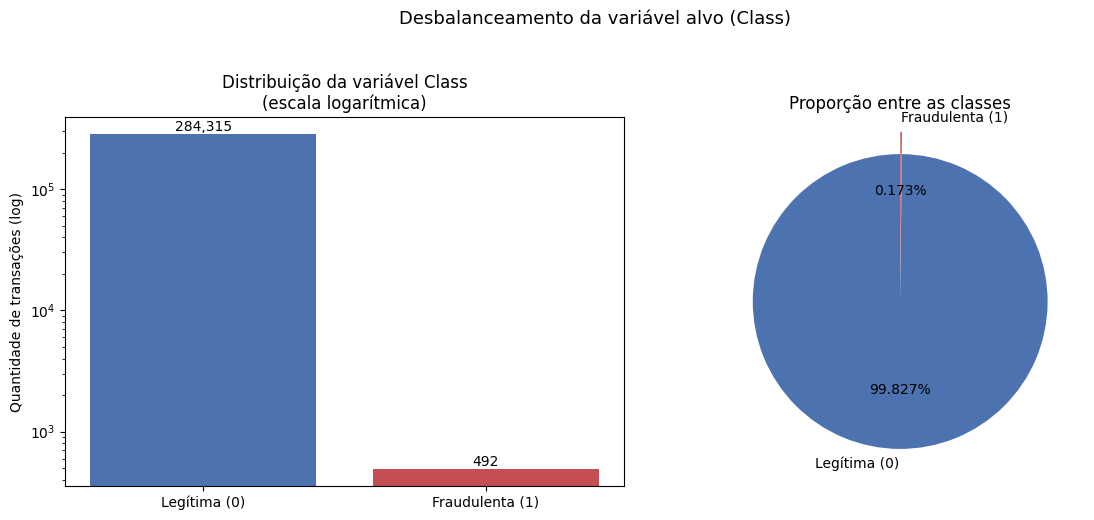

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras (contagem absoluta, escala log para visualizar as duas classes)
cores = ['#4C72B0', '#C44E52']
axes[0].bar(['Legítima (0)', 'Fraudulenta (1)'], contagem_classes.values, color=cores)
axes[0].set_yscale('log')
axes[0].set_title('Distribuição da variável Class\n(escala logarítmica)')
axes[0].set_ylabel('Quantidade de transações (log)')
for i, v in enumerate(contagem_classes.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Gráfico de pizza (percentual)
axes[1].pie(
    contagem_classes.values,
    labels=['Legítima (0)', 'Fraudulenta (1)'],
    autopct='%1.3f%%',
    colors=cores,
    startangle=90,
    explode=(0, 0.15)
)
axes[1].set_title('Proporção entre as classes')

plt.suptitle('Desbalanceamento da variável alvo', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('distribuicao_class.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão da análise exploratória

- **Qualidade dos dados:** o dataset não apresenta valores nulos (conforme seção 4) e as linhas duplicadas identificadas (seção 5) são poucas frente ao total, não comprometendo a análise.
- **Variáveis `V1`-`V28`:** já estão padronizadas via PCA, com médias próximas de zero, o que dispensa normalização adicional para esses atributos.
- **Desbalanceamento de classes:** o dataset apresenta um **forte desbalanceamento**: transações fraudulentas representam apenas cerca de **0,17%** do total de registros, contra aproximadamente **99,83%** de transações legítimas — um cenário típico e crítico em problemas de detecção de fraude.

**Implicações para as próximas etapas:**
- Métricas como *acurácia* não são adequadas para avaliar o modelo; devem ser priorizadas **precisão, recall, F1-score e AUC-PR/ROC**.
- O desbalanceamento reforça a necessidade de técnicas de balanceamento exemplo: uso de `class_weight` no split treino/teste estratificado, já conduzidos na parte da Anna Julia.
- As colunas `Amount` e `Time`, por não estarem na mesma escala das componentes PCA, devem passar por normalização antes da modelagem.
